# CSE 472: Machine Learning Sessional
## Assignment 1: Data Preprocessing & FNN Pipeline

**Student Name:** S. M Kausar Parvej  
**Student ID:** 2005076  
**Date:** December 2025

---

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

---
## Part 1: Understanding the Dataset

### 1.1 Load the Dataset

Load the Medical Student Diabetes dataset using pandas.

In [ ]:
# Load the dataset
df = pd.read_csv("medical_students_dataset.csv")
print("Dataset loaded successfully!")
df.head(10)

Dataset loaded successfully!


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No
5,6.0,32.0,NaN,151.491294,68.647805,B,29.912403,99.668373,70.0,128.0,183.0,NaN,Yes
6,7.0,21.0,NaN,172.949704,48.102744,AB,16.081635,97.715469,66.0,134.0,247.0,No,No
7,8.0,28.0,Male,186.489402,52.389752,AB,15.063921,98.227788,85.0,123.0,128.0,No,No
8,9.0,21.0,Male,155.039678,42.958703,B,NaN,98.808053,NaN,111.0,243.0,No,No
9,10.0,32.0,NaN,170.836315,50.783250,B,17.400435,98.570168,61.0,94.0,166.0,NaN,No


### 1.2 Dataset Shape

Display the number of rows (records) and columns (attributes) in the dataset.

In [ ]:
rows, columns = df.shape
print(f"Number of rows (records): {rows}")
print(f"Number of columns (attributes): {columns}")
print(f"\nDataset shape: {df.shape}")

Number of rows (records): 200000
Number of columns (attributes): 13

Dataset shape: (200000, 13)


### 1.3 Column Names and Data Types

Display all column names and their data types to understand the structure.

In [ ]:
print("Column Names:")
print(df.columns.tolist())
print("\n" + "="*60)
print("\nData Types:")
print(df.dtypes)

Column Names:
['Student ID', 'Age', 'Gender', 'Height', 'Weight', 'Blood Type', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Diabetes', 'Smoking']


Data Types:
Student ID        float64
Age               float64
Gender             object
Height            float64
Weight            float64
Blood Type         object
BMI               float64
Temperature       float64
Heart Rate        float64
Blood Pressure    float64
Cholesterol       float64
Diabetes           object
Smoking            object
dtype: object


### 1.4 Statistical Summary

Generate descriptive statistics for all numerical columns.

In [ ]:
df.describe()

,Student ID,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,49974.042078,26.021561,174.947103,69.971585,23.338869,98.600948,79.503767,114.558033,184.486361
std,28879.641657,4.890528,14.447560,17.322574,7.033554,0.500530,11.540755,14.403353,37.559678
min,1.000000,18.000000,150.000041,40.000578,10.074837,96.397835,60.000000,90.000000,120.000000
25%,24971.750000,22.000000,162.476110,54.969838,17.858396,98.264750,70.000000,102.000000,152.000000
50%,49943.500000,26.000000,174.899914,69.979384,22.671401,98.599654,80.000000,115.000000,184.000000
75%,74986.000000,30.000000,187.464417,84.980097,27.997487,98.940543,90.000000,127.000000,217.000000
max,100000.000000,34.000000,199.998639,99.999907,44.355113,100.824857,99.000000,139.000000,249.000000


### 1.5 Data Distribution Visualization

Visualize the distribution of numerical features using histograms.

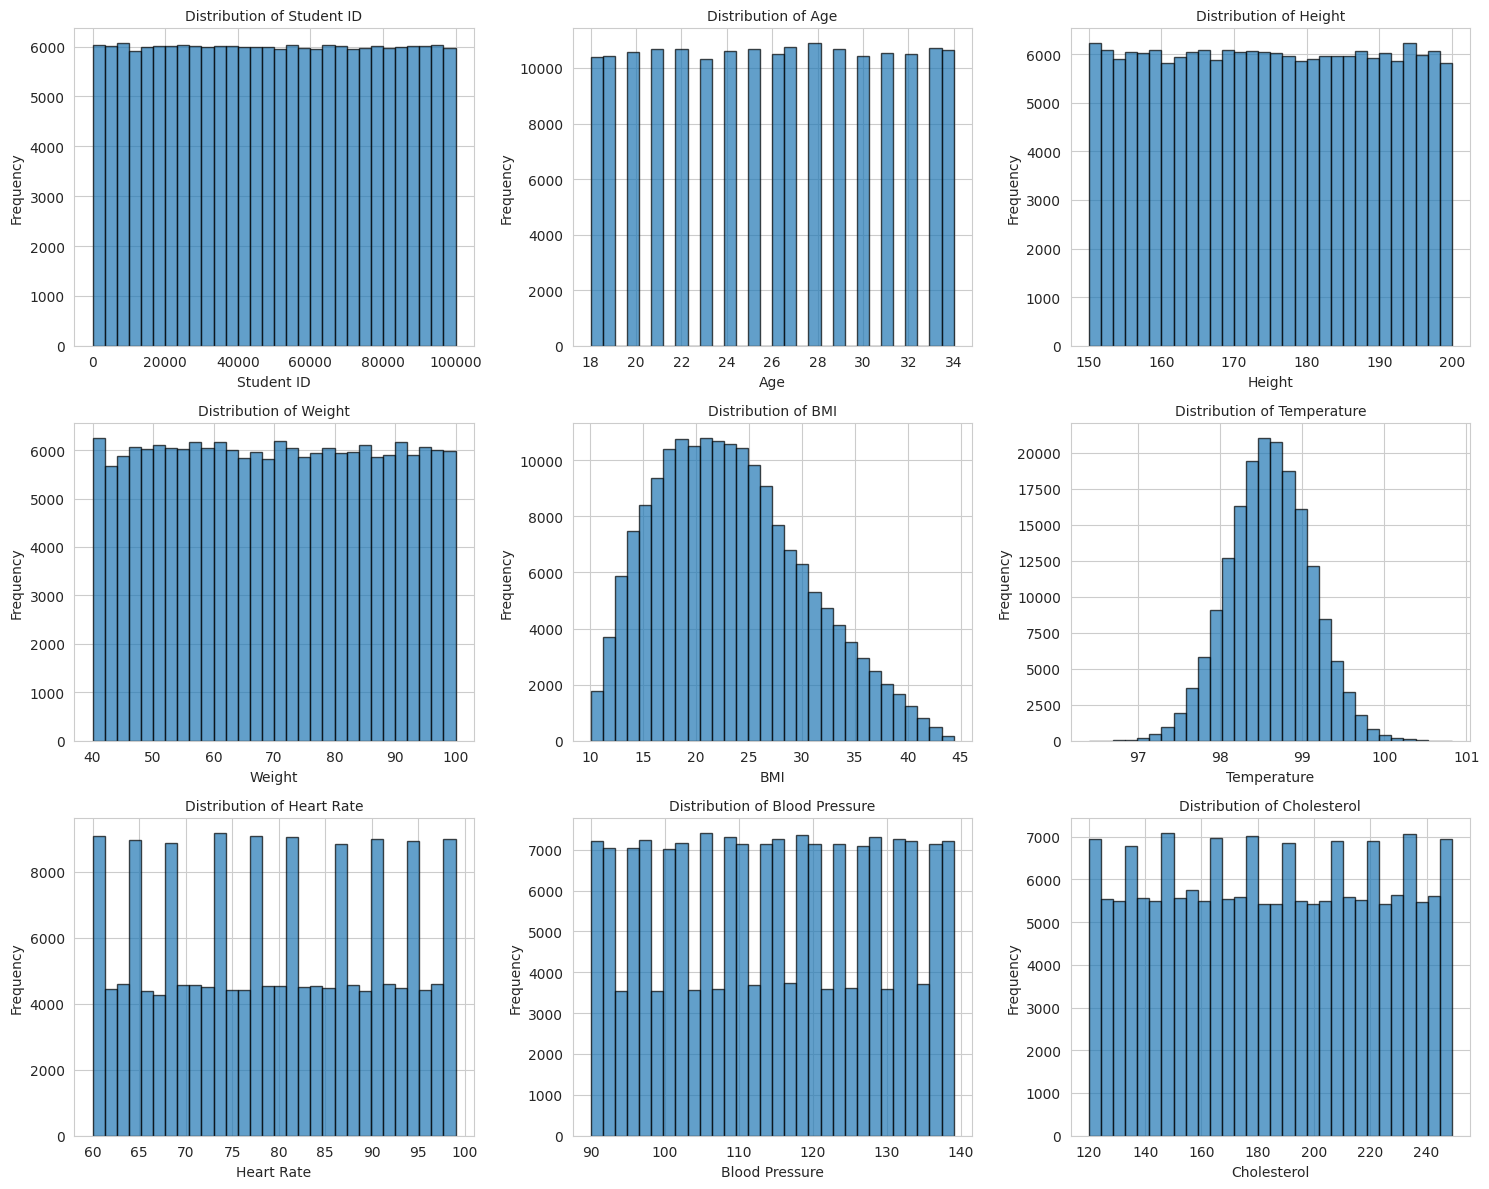

In [ ]:
# Select numerical columns for visualization
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Create subplots for numerical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:9]):
    df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=10)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 1.6 Target Variable Distribution

Visualize the distribution of the target variable (Diabetes).

Target Variable Distribution:
Diabetes
No     161986
Yes     18014
Name: count, dtype: int64

Percentage Distribution:
Diabetes
No     89.992222
Yes    10.007778
Name: proportion, dtype: float64


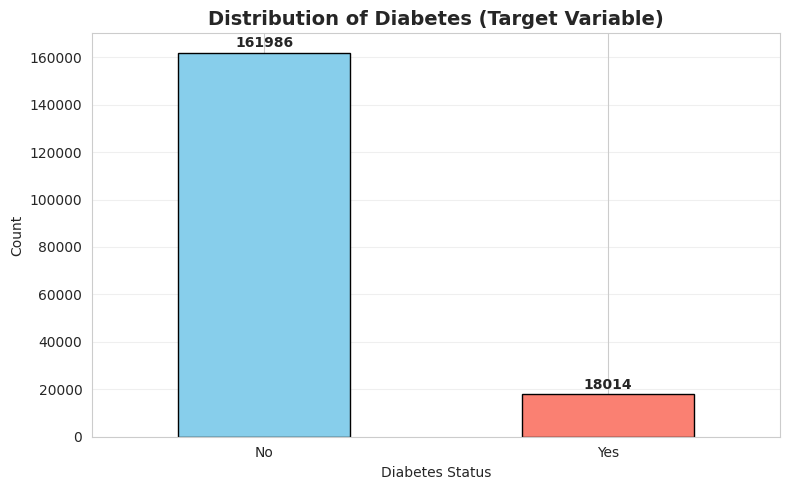

In [ ]:
# Count plot for target variable
plt.figure(figsize=(8, 5))
target_counts = df['Diabetes'].value_counts()
print("Target Variable Distribution:")
print(target_counts)
print(f"\nPercentage Distribution:")
print(df['Diabetes'].value_counts(normalize=True) * 100)

# Bar plot
ax = target_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')
plt.title('Distribution of Diabetes (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(target_counts):
    ax.text(i, v + 1000, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.7 Missing Values Analysis

Count the number of missing values in each column.

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Missing Values Summary:")
print(missing_df.to_string(index=False))
print(f"\n\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing Values Summary:
        Column  Missing Count  Percentage
    Student ID          20000        10.0
           Age          20000        10.0
        Gender          20000        10.0
        Height          20000        10.0
        Weight          20000        10.0
    Blood Type          20000        10.0
           BMI          20000        10.0
   Temperature          20000        10.0
    Heart Rate          20000        10.0
Blood Pressure          20000        10.0
   Cholesterol          20000        10.0
      Diabetes          20000        10.0
       Smoking          20000        10.0


Total missing values in dataset: 260000


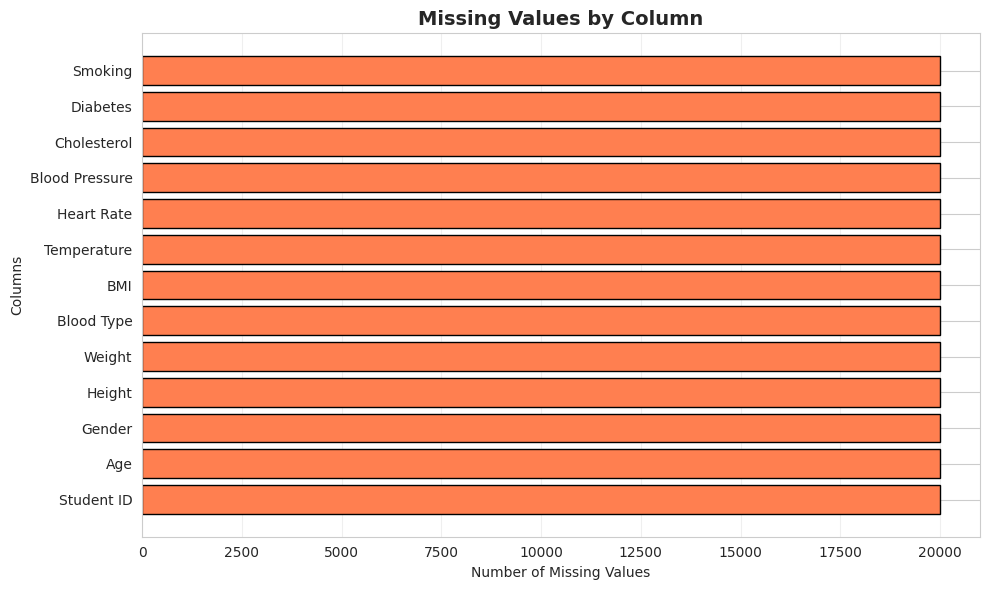

In [ ]:
# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df['Column'], missing_df['Missing Count'], color='coral', edgecolor='black')
    plt.xlabel('Number of Missing Values')
    plt.ylabel('Columns')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 1.8 Duplicate Rows Detection

Identify and count duplicate rows in the dataset.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nShowing first 10 duplicate rows:")
    duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    print(duplicates.head(10))

Number of duplicate rows: 7644

Showing first 10 duplicate rows:
        Student ID   Age  Gender      Height     Weight Blood Type        BMI  \
7              8.0  28.0    Male  186.489402  52.389752         AB  15.063921   
100007         8.0  28.0    Male  186.489402  52.389752         AB  15.063921   
11            12.0  34.0  Female  182.416302  76.371050         AB  22.950992   
100011        12.0  34.0  Female  182.416302  76.371050         AB  22.950992   
18            19.0  31.0  Female  158.790160  46.829849         AB  18.572723   
100018        19.0  31.0  Female  158.790160  46.829849         AB  18.572723   
22            23.0  29.0  Female  179.909041  90.679436         AB  28.015787   
100022        23.0  29.0  Female  179.909041  90.679436         AB  28.015787   
23            24.0  18.0    Male         NaN  52.521560         AB  13.570402   
100023        24.0  18.0    Male         NaN  52.521560         AB  13.570402   

        Temperature  Heart Rate  Blood Pres

---
## Part 2: Data Cleaning

### 2.1 Handle Missing Values in Target Column

Drop rows where the target column (Diabetes) has missing values.

In [ ]:
print(f"Rows before dropping missing target values: {len(df)}")
print(f"Missing values in 'Diabetes' column: {df['Diabetes'].isnull().sum()}")

# Drop rows where target is missing
df = df.dropna(subset=['Diabetes'])

print(f"\nRows after dropping missing target values: {len(df)}")
print(f"Missing values in 'Diabetes' column: {df['Diabetes'].isnull().sum()}")

Rows before dropping missing target values: 200000
Missing values in 'Diabetes' column: 20000

Rows after dropping missing target values: 180000
Missing values in 'Diabetes' column: 0


### 2.2 Remove Duplicate Rows

Keep only one copy of duplicate rows before imputing missing values.

In [ ]:
print(f"Rows before removing duplicates: {len(df)}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

print(f"\nRows after removing duplicates: {len(df)}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Rows before removing duplicates: 172451
Number of duplicate rows: 0

Rows after removing duplicates: 172451
Number of duplicate rows: 0


### 2.3 Handle Missing Values in Feature Columns

Replace missing values in numerical columns with column-wise mean (calculated after removing duplicates).

In [ ]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Get numerical columns (excluding target)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Fill missing values with column mean for numerical columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
        print(f"\nFilled {col} with mean: {mean_value:.2f}")

# For non-numerical columns, fill with mode (most frequent value)
non_numerical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
non_numerical_cols.remove('Diabetes')  # Don't fill target column

for col in non_numerical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"\nFilled {col} with mode: {mode_value}")

print("\n" + "="*60)
print("\nMissing values after imputation:")
print(df.isnull().sum().sum())

Missing values before imputation:
Student ID        17815
Age               17875
Gender            17953
Height            18008
Weight            17886
Blood Type        17872
BMI               17923
Temperature       17864
Heart Rate        17935
Blood Pressure    17957
Cholesterol       17823
Smoking           17912
dtype: int64

Filled Student ID with mean: 49973.20

Filled Age with mean: 26.03

Filled Height with mean: 174.95

Filled Weight with mean: 70.00

Filled BMI with mean: 23.35

Filled Temperature with mean: 98.60

Filled Heart Rate with mean: 79.50

Filled Blood Pressure with mean: 114.56

Filled Cholesterol with mean: 184.49

Filled Gender with mode: Female

Filled Blood Type with mode: O

Filled Smoking with mode: No


Missing values after imputation:
0


### 2.4 Reset Index

Reset the index after cleaning operations.

In [ ]:
df = df.reset_index(drop=True)
print("Index reset successfully!")
print(f"Final cleaned dataset shape: {df.shape}")

Index reset successfully!
Final cleaned dataset shape: (172451, 13)


---
## Part 3: Creation of Input and Output Features

### 3.1 Separate Features and Target

Split the dataset into Features (all columns except target and student_id) and Labels (target column).

In [ ]:
# Separate features and target
# Exclude 'Diabetes' (target) and 'Student ID' (identifier with no predictive value)
features = df.drop(['Diabetes', 'Student ID'], axis=1)
labels = df['Diabetes']

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nFeature columns: {features.columns.tolist()}")
print(f"\nTarget column: Diabetes")
print(f"\nTarget values: {labels.unique()}")

Features shape: (172451, 11)
Labels shape: (172451,)

Feature columns: ['Age', 'Gender', 'Height', 'Weight', 'Blood Type', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Smoking']

Target column: Diabetes

Target values: ['No' 'Yes']


---
## Part 4: Conversion of Features into Numeric Values

### 4.1 Identify Non-Numeric Columns

Identify which columns contain text/categorical data.

In [ ]:
# Identify non-numeric columns
non_numeric_cols = features.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()

print("Non-numeric columns:")
for col in non_numeric_cols:
    unique_values = features[col].unique()
    print(f"\n{col}: {unique_values} (Count: {len(unique_values)})")

print(f"\n{'='*60}")
print(f"\nNumeric columns: {numeric_cols}")

Non-numeric columns:

Gender: ['Female' 'Male'] (Count: 2)

Blood Type: ['O' 'B' 'A' 'AB'] (Count: 4)

Smoking: ['No' 'Yes'] (Count: 2)


Numeric columns: ['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']


### 4.2 Encode Target Variable

Convert the target variable from "Yes"/"No" to 1/0 using label encoding.

In [ ]:
# Label encode the target variable (Yes/No to 1/0)
labels = labels.map({'Yes': 1, 'No': 0})

print("Target variable encoding:")
print("Yes -> 1")
print("No -> 0")
print(f"\nEncoded target distribution:")
print(labels.value_counts().sort_index())

Target variable encoding:
Yes -> 1
No -> 0

Encoded target distribution:
Diabetes
0    155165
1     17286
Name: count, dtype: int64


### 4.3 Encode Categorical Features

Apply appropriate encoding to categorical features:
- **Label Encoding** for binary categorical variables (2 unique values)
- **One-Hot Encoding** for multi-class categorical variables (>2 unique values)

In [ ]:
# Identify binary and multi-class categorical columns
binary_cols = []
multi_class_cols = []

for col in non_numeric_cols:
    unique_count = features[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_class_cols.append(col)

print("Binary categorical columns (will use Label Encoding):")
print(binary_cols)
print("\nMulti-class categorical columns (will use One-Hot Encoding):")
print(multi_class_cols)

Binary categorical columns (will use Label Encoding):
['Gender', 'Smoking']

Multi-class categorical columns (will use One-Hot Encoding):
['Blood Type']


In [ ]:
# Apply Label Encoding to binary columns
for col in binary_cols:
    unique_values = sorted(features[col].unique())
    mapping = {unique_values[0]: 0, unique_values[1]: 1}
    features[col] = features[col].map(mapping)
    print(f"\n{col}: {mapping}")

print(f"\n{'='*60}")

# Convert multi-class columns to categorical type
for col in multi_class_cols:
    features[col] = features[col].astype('category')

print("\nMulti-class columns converted to categorical type.")


Gender: {'Female': 0, 'Male': 1}

Smoking: {'No': 0, 'Yes': 1}


Multi-class columns converted to categorical type.


In [ ]:
# Apply One-Hot Encoding to multi-class columns
print(f"Features shape before one-hot encoding: {features.shape}")

features = pd.get_dummies(features, columns=multi_class_cols, drop_first=False)

print(f"Features shape after one-hot encoding: {features.shape}")
print(f"\nNew columns created: {features.shape[1] - len(numeric_cols) - len(binary_cols)}")
print(f"\nAll feature columns ({len(features.columns)}):")
print(features.columns.tolist())

Features shape before one-hot encoding: (172451, 11)
Features shape after one-hot encoding: (172451, 14)

New columns created: 4

All feature columns (14):
['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Smoking', 'Blood Type_A', 'Blood Type_AB', 'Blood Type_B', 'Blood Type_O']


### 4.4 Verify All Features are Numeric

Confirm that all features are now in numeric format.

In [ ]:
# Convert boolean columns to integers
bool_cols = features.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    features[bool_cols] = features[bool_cols].astype(int)
    print(f"Converted {len(bool_cols)} boolean columns to integer")

print("\nData types after encoding:")
print(features.dtypes.value_counts())
print(f"\nAll features are numeric: {features.select_dtypes(include=[np.number]).shape[1] == features.shape[1]}")

Converted 4 boolean columns to integer

Data types after encoding:
float64    8
int64      6
Name: count, dtype: int64

All features are numeric: True


---
## Part 5: Scaling of the Features

### 5.1 Identify Columns to Scale

Identify which columns need scaling (exclude one-hot encoded and binary encoded columns).

In [ ]:
# Only scale original numerical columns
# Don't scale:
# 1. One-hot encoded columns (already in [0, 1] range)
# 2. Binary encoded columns (already in [0, 1] range from label encoding)

# Identify one-hot encoded columns (contain '_' and are binary)
one_hot_cols = [col for col in features.columns if '_' in col and features[col].nunique() <= 2 and set(features[col].unique()).issubset({0, 1, 0.0, 1.0})]

# Identify binary encoded columns (from label encoding, stored in binary_cols list)
# These are the columns that were label encoded in Part 4.3
binary_encoded_cols = binary_cols.copy()

# Columns to scale: only original numerical columns (exclude one-hot and binary encoded)
cols_not_to_scale = set(one_hot_cols + binary_encoded_cols)
cols_to_scale = [col for col in features.columns if col not in cols_not_to_scale]

print(f"Total features: {len(features.columns)}")
print(f"One-hot encoded columns (will NOT be scaled): {len(one_hot_cols)}")
print(f"Binary encoded columns (will NOT be scaled): {len(binary_encoded_cols)}")
print(f"Columns to be scaled (original numerical only): {len(cols_to_scale)}")
print(f"\nBinary encoded columns: {binary_encoded_cols}")
print(f"\nColumns to scale: {cols_to_scale}")

Total features: 14
One-hot encoded columns (will NOT be scaled): 4
Binary encoded columns (will NOT be scaled): 2
Columns to be scaled (original numerical only): 8

Binary encoded columns: ['Gender', 'Smoking']

Columns to scale: ['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']


### 5.2 Create Scaling Function

Create a functional approach to apply different scaling methods.

In [ ]:
def apply_scaling(features, columns_to_scale, method='standard'):
    """
    Apply scaling to specified columns.

    Parameters:
    - features: DataFrame containing all features
    - columns_to_scale: List of column names to scale
    - method: 'standard' for StandardScaler or 'minmax' for MinMaxScaler

    Returns:
    - Scaled features DataFrame
    - Scaler object (for potential inverse transformation)
    """
    features_scaled = features.copy()

    if method == 'standard':
        scaler = StandardScaler()
        print("Applying Standard Scaling (Z-score normalization)")
        print("Formula: z = (x - mean) / std")
    elif method == 'minmax':
        scaler = MinMaxScaler()
        print("Applying Min-Max Scaling")
        print("Formula: x_scaled = (x - min) / (max - min)")
    else:
        raise ValueError("Method must be 'standard' or 'minmax'")

    # Apply scaling only to specified columns
    features_scaled[columns_to_scale] = scaler.fit_transform(features[columns_to_scale])

    print(f"\nScaled {len(columns_to_scale)} columns")
    return features_scaled, scaler

# Example usage - we'll use this function later
print("Scaling function created successfully!")

Scaling function created successfully!


### 5.3 Apply Standard Scaling

Apply Standard Scaling (Z-score normalization) to the features.

In [ ]:
features_standard_scaled, standard_scaler = apply_scaling(features, cols_to_scale, method='standard')

print("\n" + "="*60)
print("\nFeatures after Standard Scaling:")
print(features_standard_scaled[cols_to_scale].describe())

Applying Standard Scaling (Z-score normalization)
Formula: z = (x - mean) / std

Scaled 8 columns


Features after Standard Scaling:
                Age        Height        Weight           BMI   Temperature  \
count  1.724510e+05  1.724510e+05  1.724510e+05  1.724510e+05  1.724510e+05   
mean  -1.307976e-15 -1.073987e-15  6.615075e-17 -2.216699e-16 -1.325792e-14   
std    1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00   
min   -1.733084e+00 -1.823567e+00 -1.829462e+00 -1.993516e+00 -4.653457e+00   
25%   -8.696303e-01 -8.050283e-01 -8.098103e-01 -7.405060e-01 -6.184360e-01   
50%   -1.533802e-15  2.077477e-15  0.000000e+00  0.000000e+00  0.000000e+00   
75%    8.572770e-01  8.092571e-01  8.093292e-01  5.836323e-01  6.213686e-01   
max    1.720731e+00  1.831066e+00  1.829001e+00  3.155342e+00  4.696206e+00   

         Heart Rate  Blood Pressure   Cholesterol  
count  1.724510e+05    1.724510e+05  1.724510e+05  
mean   4.861493e-16   -8.497261e-17  5.231595e-16  

### 5.4 Apply Min-Max Scaling

Apply Min-Max Scaling to the features.

In [ ]:
features_minmax_scaled, minmax_scaler = apply_scaling(features, cols_to_scale, method='minmax')

print("\n" + "="*60)
print("\nFeatures after Min-Max Scaling:")
print(features_minmax_scaled[cols_to_scale].describe())

Applying Min-Max Scaling
Formula: x_scaled = (x - min) / (max - min)

Scaled 8 columns


Features after Min-Max Scaling:
                 Age         Height         Weight            BMI  \
count  172451.000000  172451.000000  172451.000000  172451.000000   
mean        0.501788       0.498974       0.500063       0.387176   
std         0.289536       0.273626       0.273340       0.194218   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.250000       0.278698       0.278710       0.243357   
50%         0.501788       0.498974       0.500063       0.387176   
75%         0.750000       0.720407       0.721284       0.500528   
max         1.000000       1.000000       1.000000       1.000000   

         Temperature     Heart Rate  Blood Pressure    Cholesterol  
count  172451.000000  172451.000000   172451.000000  172451.000000  
mean        0.497714       0.500121        0.501315       0.499946  
std         0.106956       0.280163        0.27857

### 5.5 Compare Scaling Methods

Visualize the effect of different scaling methods on a sample feature.

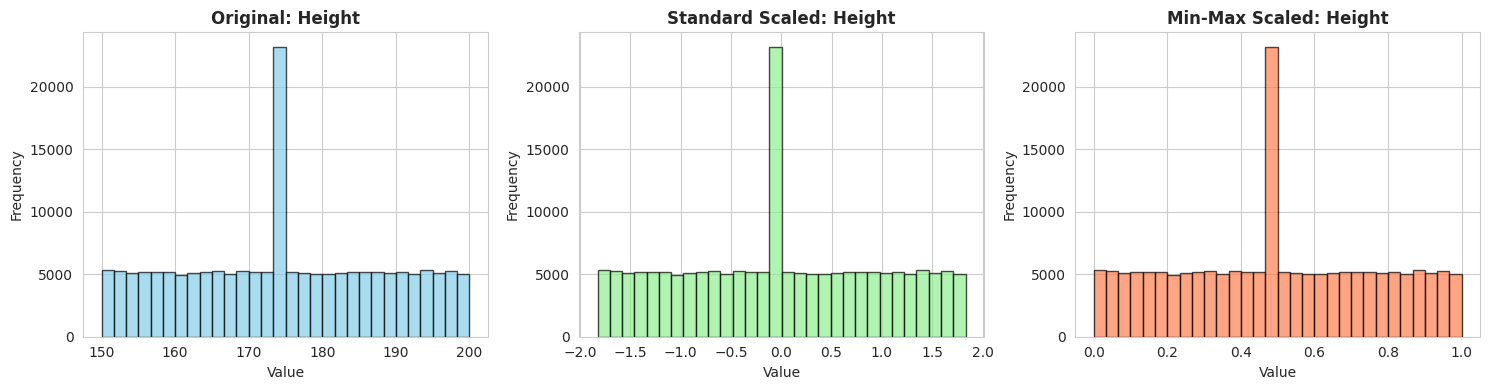

In [ ]:
# Select a sample column for visualization
sample_col = cols_to_scale[1] if cols_to_scale else features.columns[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original distribution
axes[0].hist(features[sample_col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title(f'Original: {sample_col}', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Standard scaled
axes[1].hist(features_standard_scaled[sample_col], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title(f'Standard Scaled: {sample_col}', fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

# Min-Max scaled
axes[2].hist(features_minmax_scaled[sample_col], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_title(f'Min-Max Scaled: {sample_col}', fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5.6 Select Scaling Method

For the rest of the analysis, we'll use **Standard Scaling** as it's more robust to outliers. However, you can easily switch by changing the variable assignment below.

In [ ]:
# Choose scaling method: 'standard' or 'minmax'
SCALING_METHOD = 'standard'  # Change this to 'minmax' if preferred

if SCALING_METHOD == 'standard':
    features_scaled = features_standard_scaled
    print("Using Standard Scaling for further analysis")
else:
    features_scaled = features_minmax_scaled
    print("Using Min-Max Scaling for further analysis")

print(f"\nScaled features shape: {features_scaled.shape}")

Using Standard Scaling for further analysis

Scaled features shape: (172451, 14)


---
## Part 6: Correlation Analysis

### 6.1 Compute Correlation with Target

Calculate the correlation of each feature with the target variable.

In [ ]:
# Combine features and target for correlation analysis
data_for_correlation = features_scaled.copy()
data_for_correlation['Diabetes'] = labels

# Calculate correlation with target
correlation_with_target = data_for_correlation.corr()['Diabetes'].drop('Diabetes').sort_values(ascending=False)

print("Correlation of each feature with target variable (Diabetes):")
print("="*60)
print(correlation_with_target)

Correlation of each feature with target variable (Diabetes):
Age               0.004108
Cholesterol       0.002683
Gender            0.002360
Weight            0.002345
BMI               0.001909
Heart Rate        0.001679
Blood Type_B      0.001566
Blood Type_A      0.000440
Smoking          -0.000420
Blood Type_O     -0.000559
Blood Type_AB    -0.001384
Blood Pressure   -0.001540
Temperature      -0.005865
Height           -0.006280
Name: Diabetes, dtype: float64


### 6.2 Visualize Correlation with Target

Create a bar plot showing correlations.

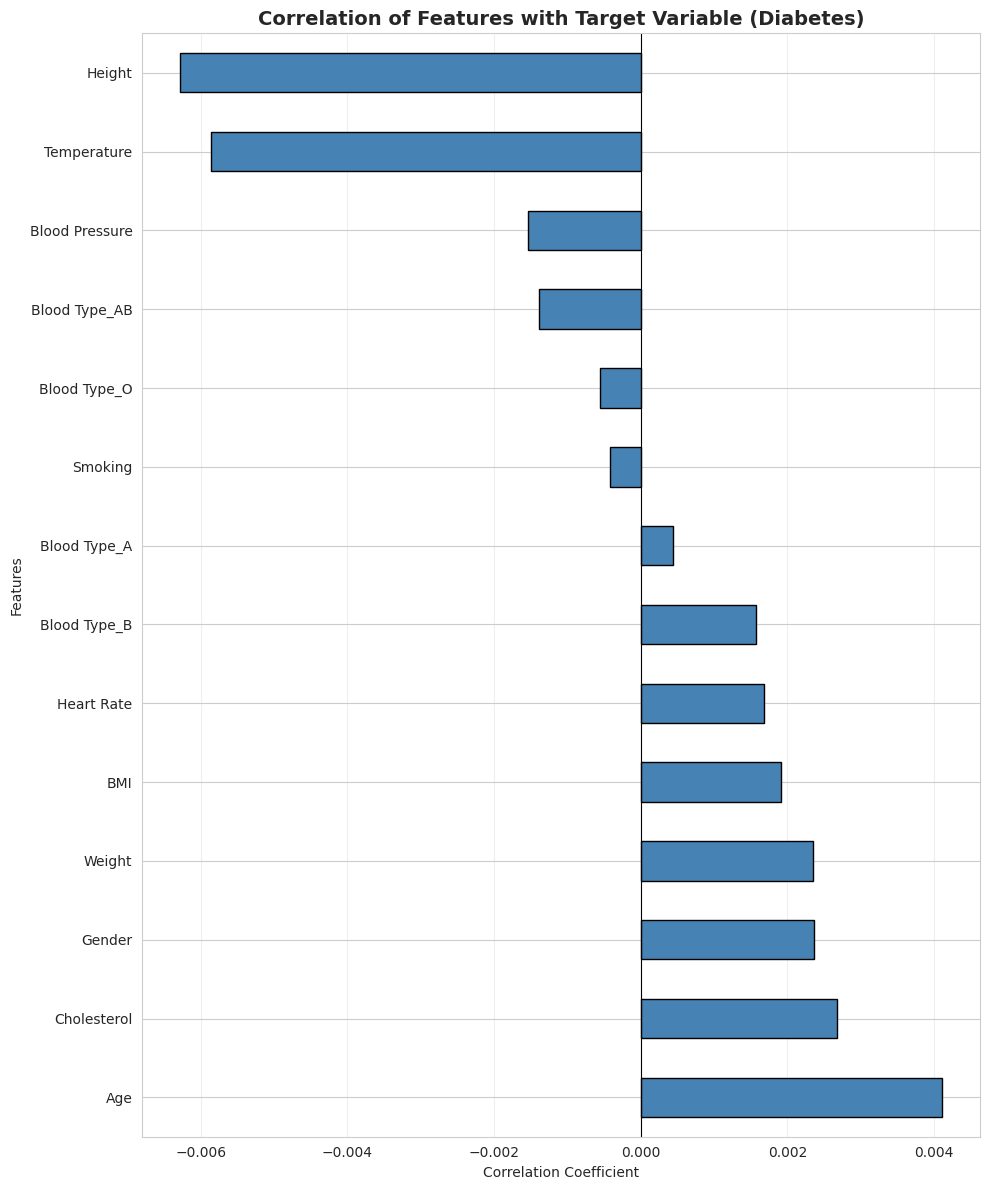

In [ ]:
# Plot correlation with target
plt.figure(figsize=(10, 12))
correlation_with_target.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Correlation of Features with Target Variable (Diabetes)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Correlation Matrix Heatmap

Visualize the full correlation matrix (showing top correlated features for clarity).

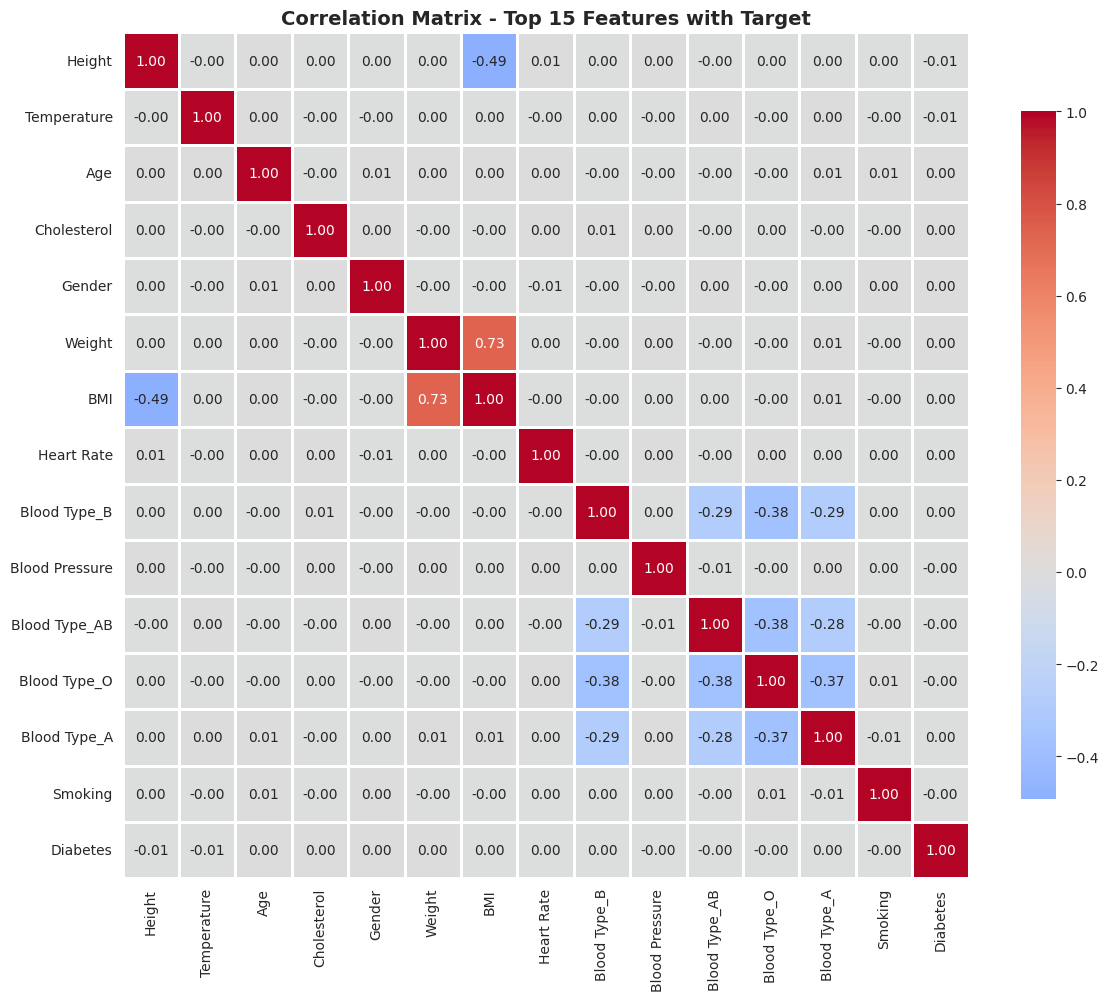

In [ ]:
# Select top features for correlation matrix visualization
top_n = 15
top_features = correlation_with_target.abs().nlargest(top_n).index.tolist()
top_features.append('Diabetes')

# Create correlation matrix for top features
corr_matrix = data_for_correlation[top_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix - Top {top_n} Features with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Select Top 10 Features

Select the 10 features with the highest absolute correlation with the target variable.

In [ ]:
# Select top 10 features based on absolute correlation
top_10_features = correlation_with_target.abs().nlargest(10).index.tolist()

print("Top 10 features with highest correlation to target:")
print("="*60)
for i, feature in enumerate(top_10_features, 1):
    corr_value = correlation_with_target[feature]
    print(f"{i}. {feature:40s} : {corr_value:+.4f}")

# Create dataset with only top 10 features
features_top10 = features_scaled[top_10_features].copy()
print(f"\n{'='*60}")
print(f"\nSelected features shape: {features_top10.shape}")

Top 10 features with highest correlation to target:
1. Height                                   : -0.0063
2. Temperature                              : -0.0059
3. Age                                      : +0.0041
4. Cholesterol                              : +0.0027
5. Gender                                   : +0.0024
6. Weight                                   : +0.0023
7. BMI                                      : +0.0019
8. Heart Rate                               : +0.0017
9. Blood Type_B                             : +0.0016
10. Blood Pressure                           : -0.0015


Selected features shape: (172451, 10)


### 6.5 1D Scatter Plots for Top Features

Visualize how each top feature separates the target classes.

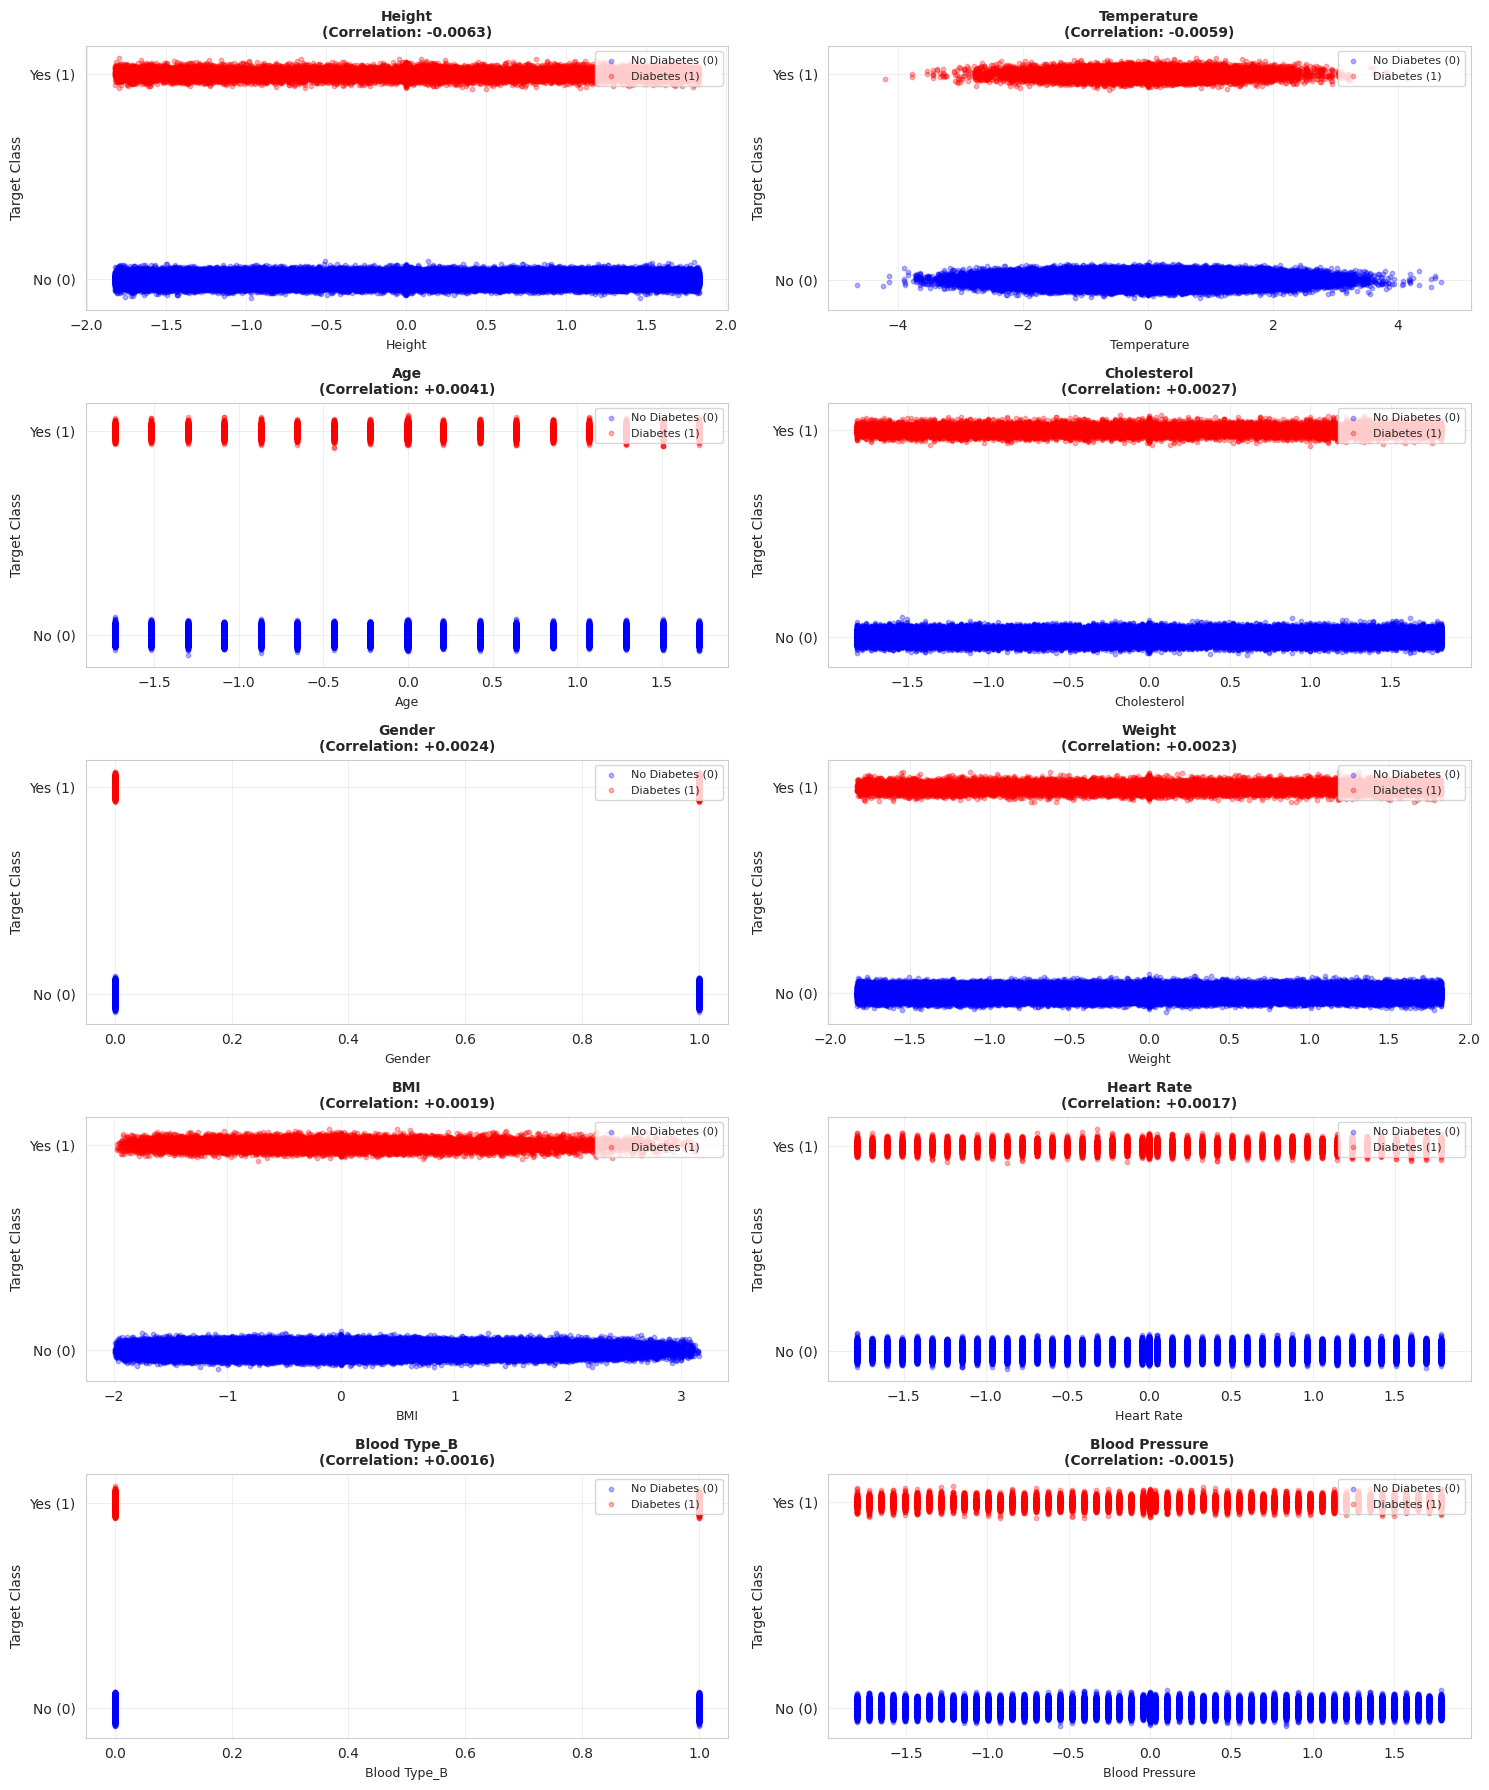

In [ ]:
# Create 1D scatter plots for top 10 features
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.ravel()

for idx, feature in enumerate(top_10_features):
    ax = axes[idx]

    # Separate data by class
    class_0 = features_scaled[labels == 0][feature]
    class_1 = features_scaled[labels == 1][feature]

    # Create scatter plot with jitter for better visualization
    y_jitter_0 = np.random.normal(0, 0.02, size=len(class_0))
    y_jitter_1 = np.random.normal(1, 0.02, size=len(class_1))

    ax.scatter(class_0, y_jitter_0, alpha=0.3, s=10, c='blue', label='No Diabetes (0)')
    ax.scatter(class_1, y_jitter_1, alpha=0.3, s=10, c='red', label='Diabetes (1)')

    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Target Class')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No (0)', 'Yes (1)'])
    ax.set_title(f'{feature}\n(Correlation: {correlation_with_target[feature]:+.4f})', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 7: Feed Forward Neural Network Pipeline

### 7.1 Prepare Data for Neural Network

Create train, validation, and test sets with stratified split (70:15:15).

In [ ]:
# Use top 10 features
X = features_top10.values
y = labels.values

print(f"Input features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(f"Class 0 (No Diabetes): {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.2f}%)")
print(f"Class 1 (Diabetes): {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.2f}%)")

Input features shape: (172451, 10)
Target shape: (172451,)

Target distribution:
Class 0 (No Diabetes): 155165 (89.98%)
Class 1 (Diabetes): 17286 (10.02%)


In [ ]:
# First split: 70% train, 30% temp (which will be split into 15% val, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Split temp into 50% validation and 50% test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Dataset split (Stratified):")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in training set:")
print(f"Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")

# Calculate class weights for handling imbalanced data
# Weight for positive class = number of negative samples / number of positive samples
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = num_neg / num_pos

print(f"\nClass imbalance ratio: {pos_weight:.2f}")
print(f"Positive class will be weighted {pos_weight:.2f}x more in loss calculation")

Dataset split (Stratified):
Training set: 120715 samples (70.0%)
Validation set: 25868 samples (15.0%)
Test set: 25868 samples (15.0%)

Class distribution in training set:
Class 0: 108615 (89.98%)
Class 1: 12100 (10.02%)

Class imbalance ratio: 8.98
Positive class will be weighted 8.98x more in loss calculation


### 7.2 Convert to PyTorch Tensors

Convert numpy arrays to PyTorch tensors and create DataLoaders.

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

DataLoaders created with batch size: 64
Number of training batches: 1887
Number of validation batches: 405
Number of test batches: 405

Using device: cuda
GPU: Tesla T4
Memory Available: 14.74 GB


### 7.3 Define Neural Network Architectures

Create multiple FNN architectures for experimentation.

In [ ]:
class FNN_Model1(nn.Module):
    """
    Architecture 1: Simple Network
    - Input Layer: 10 features
    - Hidden Layer 1: 32 neurons, ReLU
    - Hidden Layer 2: 16 neurons, ReLU
    - Output Layer: 1 neuron (no activation, using BCEWithLogitsLoss)
    """
    def __init__(self, input_size):
        super(FNN_Model1, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No sigmoid - BCEWithLogitsLoss applies it internally
        return x

class FNN_Model2(nn.Module):
    """
    Architecture 2: Wider Network
    - Input Layer: 10 features
    - Hidden Layer 1: 64 neurons, ReLU
    - Hidden Layer 2: 32 neurons, ReLU
    - Hidden Layer 3: 16 neurons, ReLU
    - Output Layer: 1 neuron (no activation, using BCEWithLogitsLoss)
    """
    def __init__(self, input_size):
        super(FNN_Model2, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # No sigmoid - BCEWithLogitsLoss applies it internally
        return x

class FNN_Model3(nn.Module):
    """
    Architecture 3: Deep Network with Dropout
    - Input Layer: 10 features
    - Hidden Layer 1: 128 neurons, ReLU, Dropout(0.3)
    - Hidden Layer 2: 64 neurons, ReLU, Dropout(0.3)
    - Hidden Layer 3: 32 neurons, ReLU
    - Output Layer: 1 neuron (no activation, using BCEWithLogitsLoss)
    """
    def __init__(self, input_size):
        super(FNN_Model3, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # No sigmoid - BCEWithLogitsLoss applies it internally
        return x

class FNN_Model4(nn.Module):
    """
    Architecture 4: Moderate Network with Batch Normalization
    - Input Layer: 10 features
    - Hidden Layer 1: 64 neurons, BatchNorm, ReLU
    - Hidden Layer 2: 48 neurons, BatchNorm, ReLU
    - Hidden Layer 3: 24 neurons, ReLU
    - Output Layer: 1 neuron (no activation, using BCEWithLogitsLoss)
    """
    def __init__(self, input_size):
        super(FNN_Model4, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 48)
        self.bn2 = nn.BatchNorm1d(48)
        self.fc3 = nn.Linear(48, 24)
        self.fc4 = nn.Linear(24, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # No sigmoid - BCEWithLogitsLoss applies it internally
        return x

print("Four FNN architectures defined successfully!")

Four FNN architectures defined successfully!


### 7.4 Training Function

Define a function to train the neural network.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=50, model_name="Model"):
    """
    Train a neural network model and track training/validation metrics.

    Parameters:
    - device: torch.device to run training on (CPU or CUDA)

    Returns:
    - Trained model
    - Training history (loss and accuracy)
    """
    model = model.to(device)
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_loss = float('inf')
    best_model_state = None

    print(f"\nTraining {model_name}...")
    print("="*60)

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            # Apply sigmoid to logits for prediction
            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (predicted == batch_y).sum().item()
            train_total += batch_y.size(0)
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # Move data to device
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                # Apply sigmoid to logits for prediction
                predicted = (torch.sigmoid(outputs) >= 0.5).float()
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Save best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest validation loss: {best_val_loss:.4f}")
    print("="*60)

    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies,
        'best_val_loss': best_val_loss
    }

    return model, history

print("Training function defined successfully!")

Training function defined successfully!


### 7.5 Train All Models

Train each architecture and save their histories.

In [ ]:
# Training configuration
input_size = X_train.shape[1]
num_epochs = 50  # Increased for better convergence
learning_rate = 0.0001  # Lower learning rate for stable training with imbalanced data

# Dictionary to store all models and histories
models_dict = {}
histories_dict = {}

# Define models
models_to_train = {
    'Model 1 (Simple)': FNN_Model1(input_size),
    'Model 2 (Wider)': FNN_Model2(input_size),
    'Model 3 (Deep + Dropout)': FNN_Model3(input_size),
    'Model 4 (BatchNorm)': FNN_Model4(input_size)
}

# Train each model
for model_name, model in models_to_train.items():
    # Use weighted loss to handle class imbalance
    # pos_weight: how much more to weight positive class errors
    pos_weight_tensor = torch.tensor([pos_weight]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    trained_model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer, device,
        num_epochs=num_epochs, model_name=model_name
    )

    models_dict[model_name] = trained_model
    histories_dict[model_name] = history
    print("\n")

print("All models trained successfully!")



Training Model 1 (Simple)...
Epoch [1/50] - Train Loss: 1.2480, Train Acc: 0.5575 | Val Loss: 1.2480, Val Acc: 0.6762
Epoch [10/50] - Train Loss: 1.2462, Train Acc: 0.5542 | Val Loss: 1.2473, Val Acc: 0.5043
Epoch [20/50] - Train Loss: 1.2448, Train Acc: 0.5083 | Val Loss: 1.2472, Val Acc: 0.4992
Epoch [30/50] - Train Loss: 1.2436, Train Acc: 0.5252 | Val Loss: 1.2473, Val Acc: 0.5032
Epoch [40/50] - Train Loss: 1.2419, Train Acc: 0.5157 | Val Loss: 1.2473, Val Acc: 0.5372
Epoch [50/50] - Train Loss: 1.2406, Train Acc: 0.5258 | Val Loss: 1.2476, Val Acc: 0.5431

Best validation loss: 1.2472



Training Model 2 (Wider)...
Epoch [1/50] - Train Loss: 1.2494, Train Acc: 0.7203 | Val Loss: 1.2479, Val Acc: 0.4849
Epoch [10/50] - Train Loss: 1.2450, Train Acc: 0.5137 | Val Loss: 1.2469, Val Acc: 0.6155
Epoch [20/50] - Train Loss: 1.2410, Train Acc: 0.5150 | Val Loss: 1.2472, Val Acc: 0.5547
Epoch [30/50] - Train Loss: 1.2367, Train Acc: 0.5389 | Val Loss: 1.2488, Val Acc: 0.5158
Epoch [40/5

### 7.6 Compare Training Histories

Visualize training and validation loss for all models.

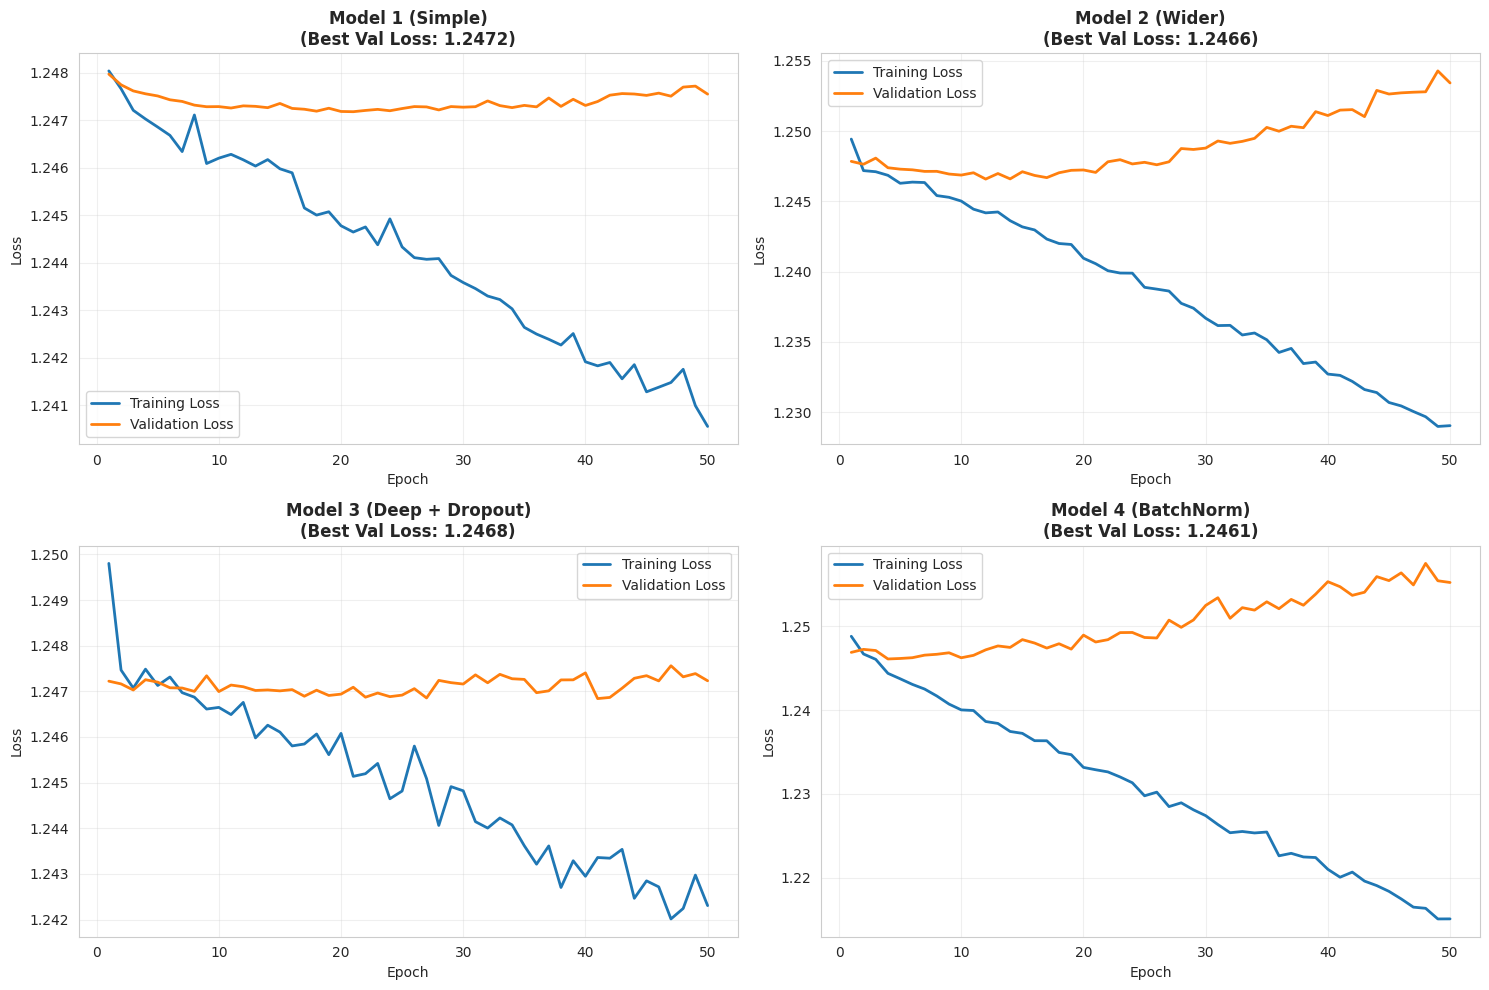

In [ ]:
# Plot training and validation loss for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, (model_name, history) in enumerate(histories_dict.items()):
    ax = axes[idx]
    epochs = range(1, len(history['train_loss']) + 1)

    ax.plot(epochs, history['train_loss'], label='Training Loss', linewidth=2)
    ax.plot(epochs, history['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'{model_name}\n(Best Val Loss: {history["best_val_loss"]:.4f})', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.7 Select Best Model

Select the model with the lowest validation loss.

In [ ]:
# Find best model based on validation loss
best_model_name = min(histories_dict, key=lambda k: histories_dict[k]['best_val_loss'])
best_model = models_dict[best_model_name]
best_history = histories_dict[best_model_name]

print("Model Comparison Summary:")
print("="*60)
for model_name, history in histories_dict.items():
    print(f"{model_name:30s} - Best Val Loss: {history['best_val_loss']:.4f}")

print("\n" + "="*60)
print(f"\nBest Model: {best_model_name}")
print(f"Best Validation Loss: {best_history['best_val_loss']:.4f}")

Model Comparison Summary:
Model 1 (Simple)               - Best Val Loss: 1.2472
Model 2 (Wider)                - Best Val Loss: 1.2466
Model 3 (Deep + Dropout)       - Best Val Loss: 1.2468
Model 4 (BatchNorm)            - Best Val Loss: 1.2461


Best Model: Model 4 (BatchNorm)
Best Validation Loss: 1.2461


---
## Part 8: Model Evaluation

### 8.1 Evaluate on Test Set

Evaluate the best model on the test set and calculate all required metrics.

In [ ]:
# Evaluate on test set
best_model.eval()
y_pred_proba = []
y_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Move data to device
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = best_model(batch_X)
        # Apply sigmoid to convert logits to probabilities
        proba = torch.sigmoid(outputs)
        y_pred_proba.extend(proba.cpu().numpy())
        y_true.extend(batch_y.cpu().numpy())

y_pred_proba = np.array(y_pred_proba).flatten()
y_true = np.array(y_true).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auroc = roc_auc_score(y_true, y_pred_proba)

print("Test Set Performance Metrics:")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUROC:     {auroc:.4f}")

Test Set Performance Metrics:
Accuracy:  0.5204
Precision: 0.1058
F1-Score:  0.1751
AUROC:     0.5281


### 8.2 Confusion Matrix

Display the confusion matrix.

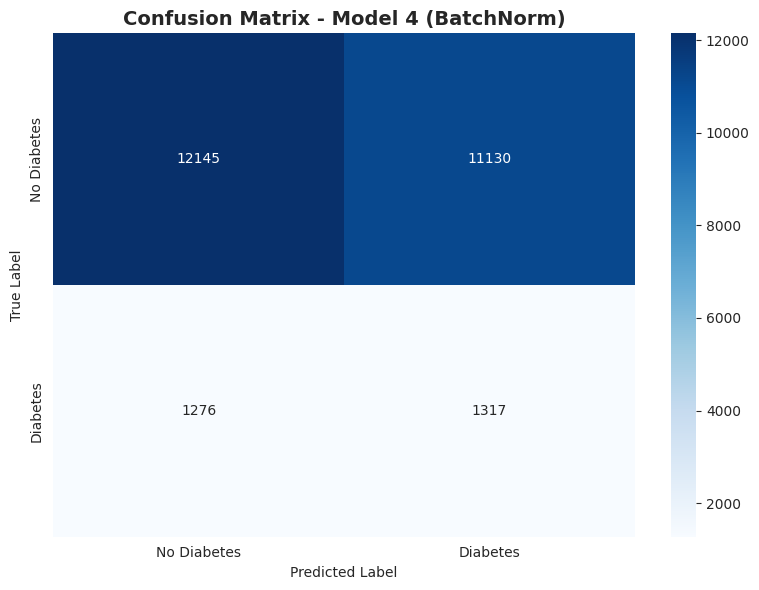


Confusion Matrix:
True Negatives:  12145
False Positives: 11130
False Negatives: 1276
True Positives:  1317


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

### 8.3 ROC Curve and AUROC

Plot the ROC curve and display the AUROC score.

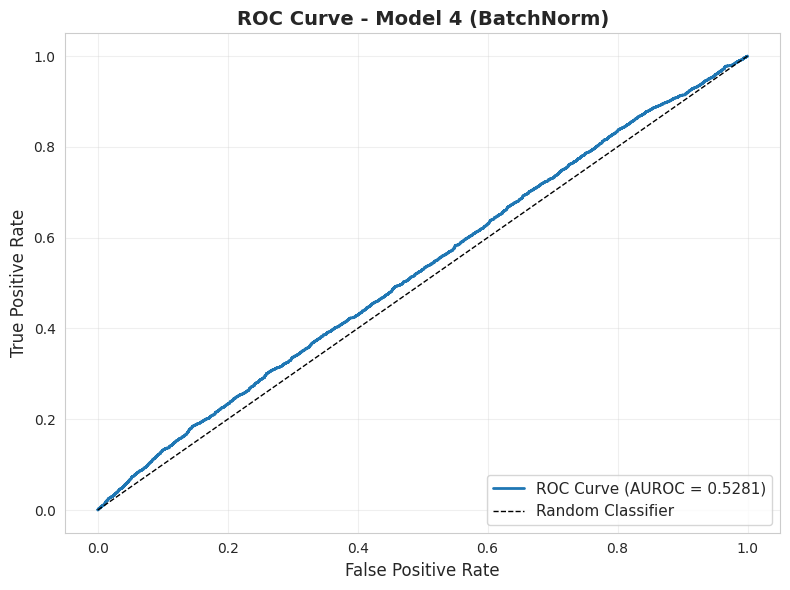

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUROC = {auroc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Final Summary

Summary of the entire pipeline and results.

In [ ]:
print("="*70)
print("ASSIGNMENT 1: DATA PREPROCESSING & FNN PIPELINE - FINAL SUMMARY")
print("="*70)

print("\n1. DATASET INFORMATION:")
print(f"   - Original dataset: {rows} rows, {columns} columns")
print(f"   - After cleaning: {len(df)} rows")
print(f"   - Features after encoding: {features.shape[1]}")
print(f"   - Top features selected: {len(top_10_features)}")

print("\n2. DATA PREPROCESSING:")
print(f"   - Missing values handled: Yes (mean imputation)")
print(f"   - Duplicates removed: Yes")
print(f"   - Encoding method: Label Encoding (binary), One-Hot (multi-class)")
print(f"   - Scaling method: {SCALING_METHOD.title()}")

print("\n3. FEATURE SELECTION:")
print(f"   - Top 10 features based on correlation with target")
print(f"   - Selected features: {', '.join(top_10_features[:5])}...")

print("\n4. NEURAL NETWORK:")
print(f"   - Number of architectures tested: {len(models_dict)}")
print(f"   - Best model: {best_model_name}")
print(f"   - Training epochs: {num_epochs}")
print(f"   - Learning rate: {learning_rate}")
print(f"   - Loss function: Binary Cross Entropy")
print(f"   - Optimizer: Adam")

print("\n5. TEST SET PERFORMANCE:")
print(f"   - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   - Precision: {precision:.4f}")
print(f"   - F1-Score:  {f1:.4f}")
print(f"   - AUROC:     {auroc:.4f}")

print("\n" + "="*70)
print("Assignment completed successfully!")
print("="*70)

ASSIGNMENT 1: DATA PREPROCESSING & FNN PIPELINE - FINAL SUMMARY

1. DATASET INFORMATION:
   - Original dataset: 200000 rows, 13 columns
   - After cleaning: 172451 rows
   - Features after encoding: 14
   - Top features selected: 10

2. DATA PREPROCESSING:
   - Missing values handled: Yes (mean imputation)
   - Duplicates removed: Yes
   - Encoding method: Label Encoding (binary), One-Hot (multi-class)
   - Scaling method: Standard

3. FEATURE SELECTION:
   - Top 10 features based on correlation with target
   - Selected features: Height, Temperature, Age, Cholesterol, Gender...

4. NEURAL NETWORK:
   - Number of architectures tested: 4
   - Best model: Model 4 (BatchNorm)
   - Training epochs: 50
   - Learning rate: 0.0001
   - Loss function: Binary Cross Entropy
   - Optimizer: Adam

5. TEST SET PERFORMANCE:
   - Accuracy:  0.5204 (52.04%)
   - Precision: 0.1058
   - F1-Score:  0.1751
   - AUROC:     0.5281

Assignment completed successfully!


---
## Appendix: Model Architectures Summary

### Architecture Details

**Model 1 (Simple Network)**
- Input Layer: 10 features
- Hidden Layer 1: 32 neurons, ReLU activation
- Hidden Layer 2: 16 neurons, ReLU activation
- Output Layer: 1 neuron (logits output)
- Parameters: ~700
- Loss Function: Binary Cross Entropy with Logits (includes sigmoid)
- Optimizer: Adam (lr=0.0001, weight_decay=1e-5)
- Class Weighting: Yes (pos_weight for imbalanced data)

**Model 2 (Wider Network)**
- Input Layer: 10 features
- Hidden Layer 1: 64 neurons, ReLU activation
- Hidden Layer 2: 32 neurons, ReLU activation
- Hidden Layer 3: 16 neurons, ReLU activation
- Output Layer: 1 neuron (logits output)
- Parameters: ~3,000
- Loss Function: Binary Cross Entropy with Logits (includes sigmoid)
- Optimizer: Adam (lr=0.0001, weight_decay=1e-5)
- Class Weighting: Yes (pos_weight for imbalanced data)

**Model 3 (Deep Network with Dropout)**
- Input Layer: 10 features
- Hidden Layer 1: 128 neurons, ReLU activation, Dropout(0.3)
- Hidden Layer 2: 64 neurons, ReLU activation, Dropout(0.3)
- Hidden Layer 3: 32 neurons, ReLU activation
- Output Layer: 1 neuron (logits output)
- Parameters: ~13,000
- Loss Function: Binary Cross Entropy with Logits (includes sigmoid)
- Optimizer: Adam (lr=0.0001, weight_decay=1e-5)
- Regularization: Dropout for preventing overfitting + L2 weight decay
- Class Weighting: Yes (pos_weight for imbalanced data)

**Model 4 (Batch Normalization)**
- Input Layer: 10 features
- Hidden Layer 1: 64 neurons, Batch Normalization, ReLU activation
- Hidden Layer 2: 48 neurons, Batch Normalization, ReLU activation
- Hidden Layer 3: 24 neurons, ReLU activation
- Output Layer: 1 neuron (logits output)
- Parameters: ~6,000
- Loss Function: Binary Cross Entropy with Logits (includes sigmoid)
- Optimizer: Adam (lr=0.0001, weight_decay=1e-5)
- Regularization: Batch Normalization for stable training + L2 weight decay
- Class Weighting: Yes (pos_weight for imbalanced data)

---
## Additional Visualizations (Bonus)

### Distribution of Features by Target Class

Box plots showing feature distributions separated by target class.

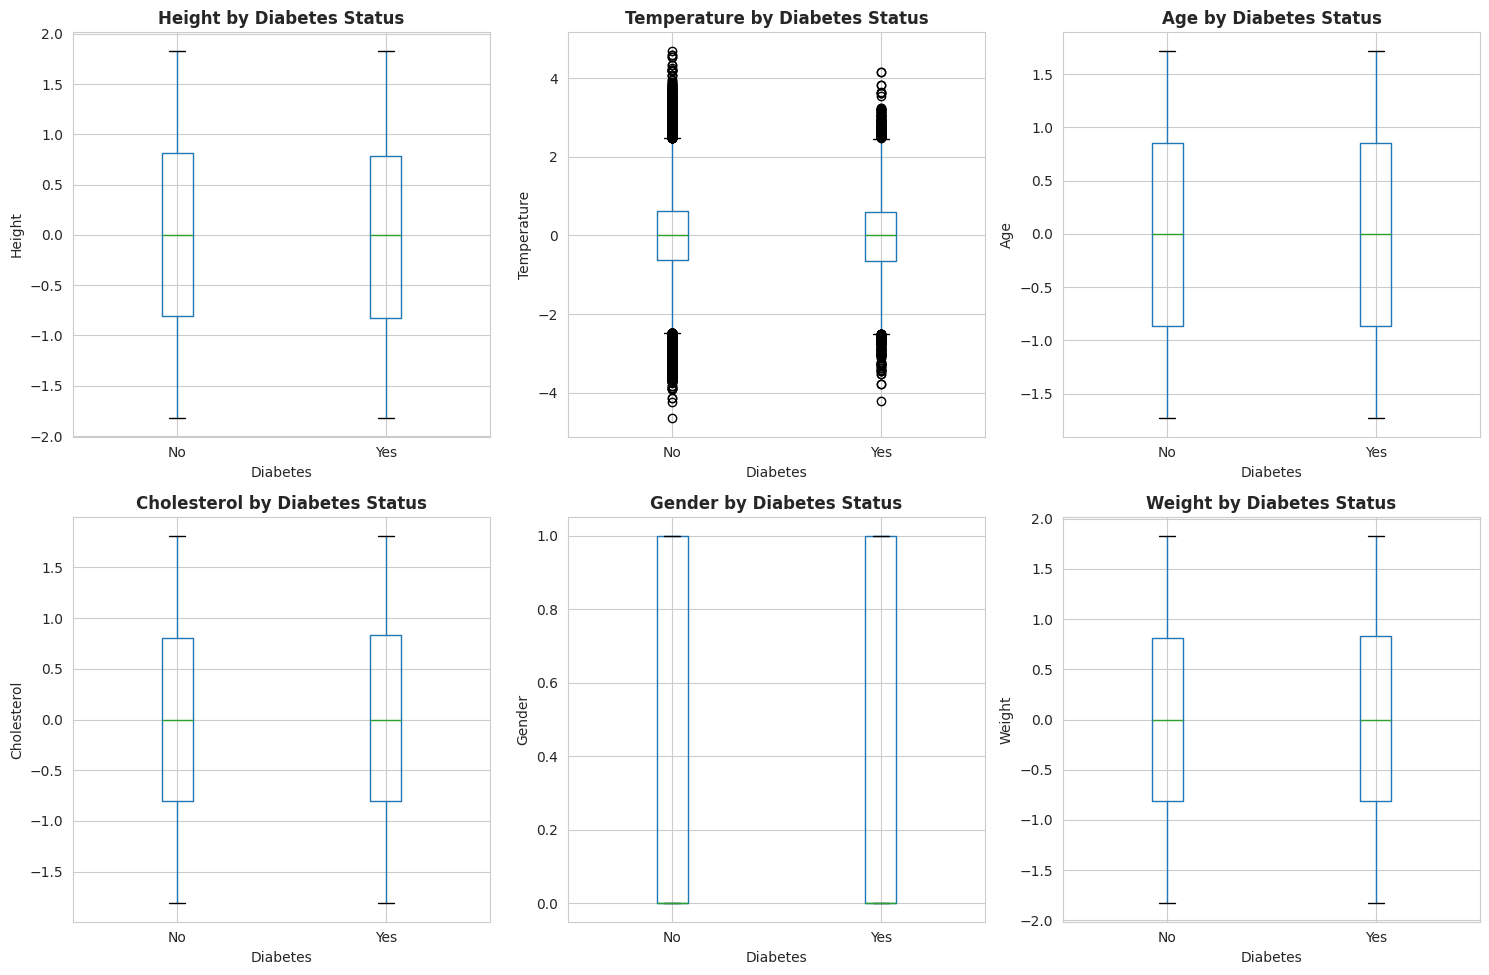

In [ ]:
# Box plots for top 5 features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

data_for_viz = features_scaled.copy()
data_for_viz['Diabetes'] = labels

for idx, feature in enumerate(top_10_features[:6]):
    ax = axes[idx]
    data_for_viz.boxplot(column=feature, by='Diabetes', ax=ax)
    ax.set_title(f'{feature} by Diabetes Status', fontweight='bold')
    ax.set_xlabel('Diabetes')
    ax.set_ylabel(feature)
    plt.sca(ax)
    plt.xticks([1, 2], ['No', 'Yes'])

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.show()

### Learning Curves

Detailed learning curves showing both loss and accuracy.

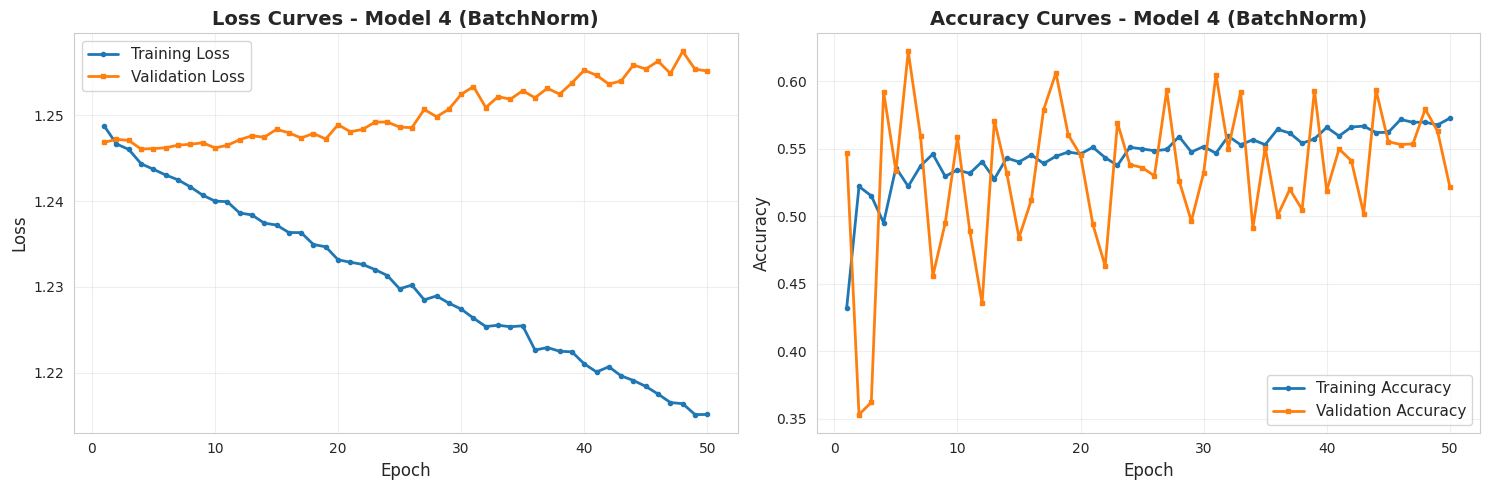

In [ ]:
# Detailed learning curves for best model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(best_history['train_loss']) + 1)

# Loss curves
ax1.plot(epochs, best_history['train_loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
ax1.plot(epochs, best_history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=3)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f'Loss Curves - {best_model_name}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Accuracy curves
ax2.plot(epochs, best_history['train_acc'], label='Training Accuracy', linewidth=2, marker='o', markersize=3)
ax2.plot(epochs, best_history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s', markersize=3)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'Accuracy Curves - {best_model_name}', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Assignment Completed

All tasks done:
1. Dataset understanding and exploration
2. Data cleaning (missing values, duplicates)  
3. Feature extraction (Features/Labels split)
4. Categorical encoding (label + one-hot)
5. Feature scaling (Standard & MinMax)
6. Correlation analysis (top 10 features selected)
7. FNN training (4 architectures tested)
8. Model evaluation (Accuracy, Precision, F1, AUROC)